# **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

# **Load Dataset**

In [3]:
file_path = 'RealEstate_HousePrice_Dataset.csv'

df = pd.read_csv(file_path)

print(df.head())

   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  \
0              11.9           5220           1         0   
1              15.8           3882           1         0   
2              21.1           4488           0         0   
3               7.9           3614           1         1   
4              24.0           2663           0         0   

   renovation_years_ago  house_price_inr  
0                     0         40275084  
1                    13         26812029  
2                     9         29315677  
3                     

# **Dataset Information**

In [4]:
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None
house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score   

# **Display Column Names**

In [5]:
print(df.columns)

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')


# **Define Independent and Dependent Variables**

In [6]:
X = df.drop('house_price_inr', axis=1)

y = df['house_price_inr']

# **Convert Categorical Data**

In [7]:
X = pd.get_dummies(X, drop_first=True)

# **Data Visualization**

**Correlation Heatmap**

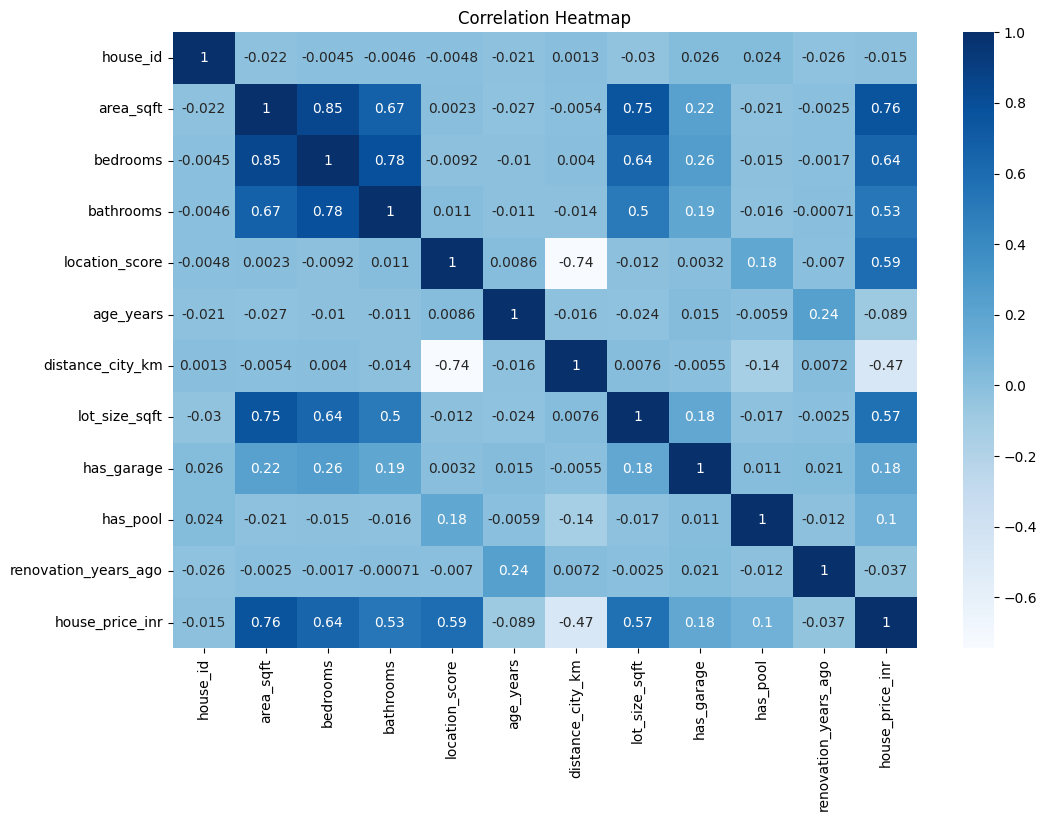

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

**Scatter Plot**

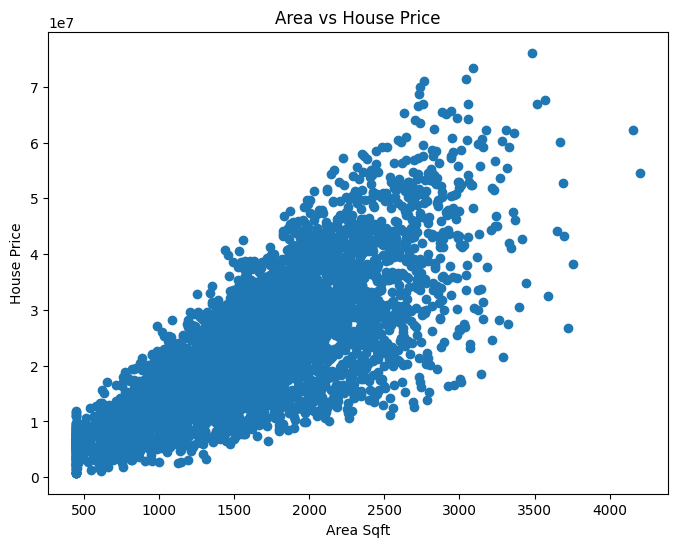

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(df['area_sqft'], df['house_price_inr'])
plt.xlabel('Area Sqft')
plt.ylabel('House Price')
plt.title('Area vs House Price')
plt.show()

# **Split Dataset**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Simple Linear Regression**
**Use Single Feature**

In [11]:
X_simple = df[['area_sqft']]
y_simple = df['house_price_inr']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

**Train Simple Linear Regression Model**

In [12]:
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

LinearRegression()

**Predictions**

In [13]:
y_pred_simple = simple_model.predict(X_test_s)

# **Plot Regression Line**

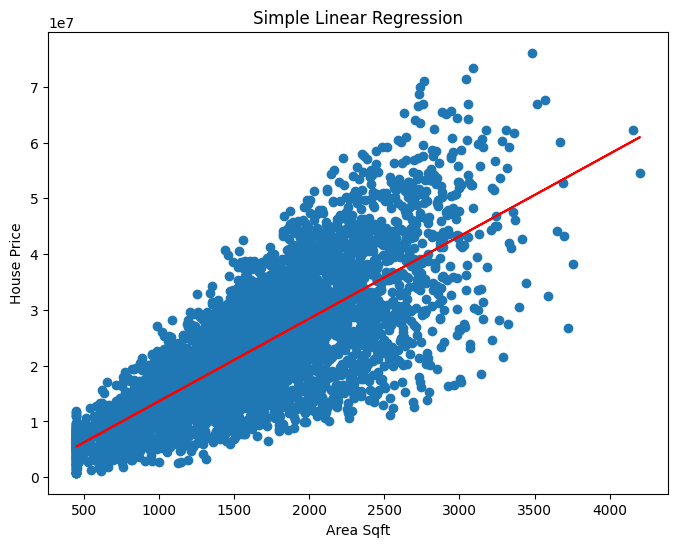

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X_simple, y_simple)
plt.plot(X_simple, simple_model.predict(X_simple), color='red')
plt.xlabel('Area Sqft')
plt.ylabel('House Price')
plt.title('Simple Linear Regression')
plt.show()

# **Model Evaluation**

In [29]:
mse = mean_squared_error(y_test_s, y_pred_simple)
mae = mean_absolute_error(y_test_s, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, y_pred_simple)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R2 Score: 0.5625199587991578


# **Residual Plot**

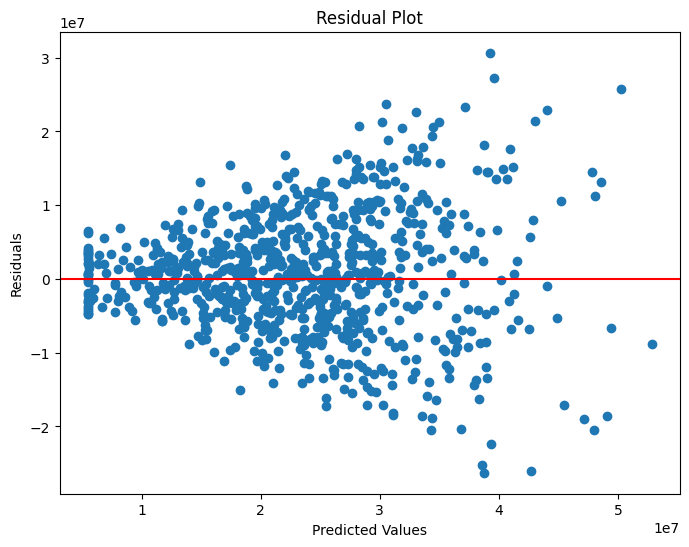

In [16]:
residuals = y_test_s - y_pred_simple

plt.figure(figsize=(8,6))
plt.scatter(y_pred_simple, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# **Multiple Linear Regression**
**Train Multiple Linear Regression Model**

In [17]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

LinearRegression()

**Predictions**

In [18]:
y_pred_multi = multi_model.predict(X_test)

**Evaluate Multiple Regression**

In [19]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print('MSE:', mse_multi)
print('RMSE:', rmse_multi)
print('R2 Score:', r2_multi)

MSE: 12597222158307.7
RMSE: 3549256.5641705445
R2 Score: 0.9177325847899332


# **Polynomial Regression**
**Polynomial Regression**

In [20]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train_s, y_train_s)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

**Polynomial Predictions**

In [21]:
y_pred_poly = poly_model.predict(X_test_s)

**Evaluate Polynomial Regression**

In [22]:
poly_r2 = r2_score(y_test_s, y_pred_poly)

print('Polynomial Regression R2 Score:', poly_r2)

Polynomial Regression R2 Score: 0.5626917978136476


# **Feature Scaling**

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Batch Gradient Descent**

In [24]:
batch_model = SGDRegressor(
    max_iter=1000,
    eta0=0.01,
    learning_rate='constant',
    random_state=42
)

batch_model.fit(X_scaled, y)

SGDRegressor(learning_rate='constant', random_state=42)

# **Stochastic Gradient Descent**

In [25]:
sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='optimal',
    random_state=42
)

sgd_model.fit(X_scaled, y)

SGDRegressor(learning_rate='optimal', random_state=42)